In [7]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from dowhy import CausalModel
import networkx as nx
import matplotlib.pyplot as plt
import statsmodels.api as sm
# Load your dataset
file_path = "Extracted_LR_Selected_Features.xlsx"  # Replace with your file
df = pd.read_excel(file_path, sheet_name="AFHRI_AOC_Combined")  # Adjust sheet_name 

In [3]:
# do calculus
treatments = [col for col in df.columns if col in ["acei", "arb", "bb", "ccb", "diuretic"]]
#metabolites = [col for col in df.columns if col.startswith("AGN_")]
metabolites = [col for col in df.columns if col.startswith("AGN_") or col.startswith("AGP_")]

confounders = ["sbp"]

results = []

for treatment in treatments:
    for outcome in metabolites:
        try:
            data = df[[treatment, outcome] + confounders].dropna()
            X = sm.add_constant(data[[treatment] + confounders])
            y = data[outcome]
            model = sm.OLS(y, X).fit()

            coef = model.params[treatment]
            pval = model.pvalues[treatment]
            ci_lower, ci_upper = model.conf_int().loc[treatment]

            results.append({
                "treatment": treatment,
                "outcome": outcome,
                "effect": coef,
                "p_value": pval,
                "ci_lower": ci_lower,
                "ci_upper": ci_upper
            })
        except Exception as e:
            print(f"Skipping {treatment} → {outcome}: {e}")

# Save results
results_df = pd.DataFrame(results)
results_df.to_csv("causal_effects_detailed2.csv", index=False)  # Adjust file name 


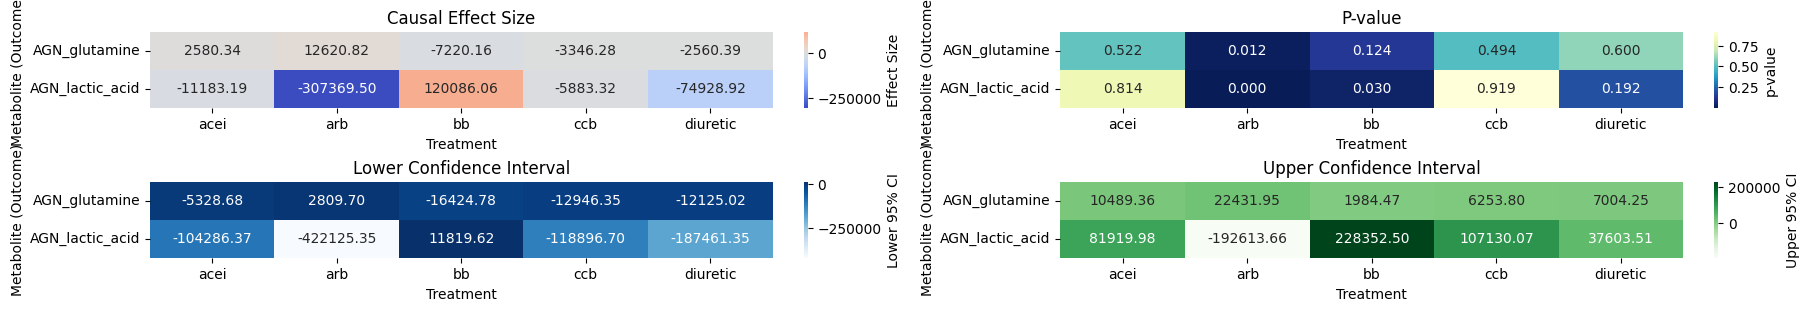

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load detailed results file
df = pd.read_csv("causal_effects_detailed2.csv")

# Pivot matrices
effect_matrix = df.pivot(index="outcome", columns="treatment", values="effect")
pval_matrix = df.pivot(index="outcome", columns="treatment", values="p_value")
ci_lower_matrix = df.pivot(index="outcome", columns="treatment", values="ci_lower")
ci_upper_matrix = df.pivot(index="outcome", columns="treatment", values="ci_upper")

# Set up the figure
fig, axes = plt.subplots(2, 2, figsize=(18, 1.5 * len(effect_matrix)), constrained_layout=True)

# Plot 1: Effect
sns.heatmap(effect_matrix, ax=axes[0, 0], cmap="coolwarm", center=0, annot=True, fmt=".2f",
            cbar_kws={"label": "Effect Size"})
axes[0, 0].set_title("Causal Effect Size")

# Plot 2: P-value
sns.heatmap(pval_matrix, ax=axes[0, 1], cmap="YlGnBu_r", annot=True, fmt=".3f",
            cbar_kws={"label": "p-value"})
axes[0, 1].set_title("P-value")

# Plot 3: Lower CI
sns.heatmap(ci_lower_matrix, ax=axes[1, 0], cmap="Blues", annot=True, fmt=".2f",
            cbar_kws={"label": "Lower 95% CI"})
axes[1, 0].set_title("Lower Confidence Interval")

# Plot 4: Upper CI
sns.heatmap(ci_upper_matrix, ax=axes[1, 1], cmap="Greens", annot=True, fmt=".2f",
            cbar_kws={"label": "Upper 95% CI"})
axes[1, 1].set_title("Upper Confidence Interval")

# Common labels
for ax in axes.flat:
    ax.set_xlabel("Treatment")
    ax.set_ylabel("Metabolite (Outcome)")

# Save and show
#plt.savefig("causal_effects_all_metrics.png", dpi=300)
plt.show()


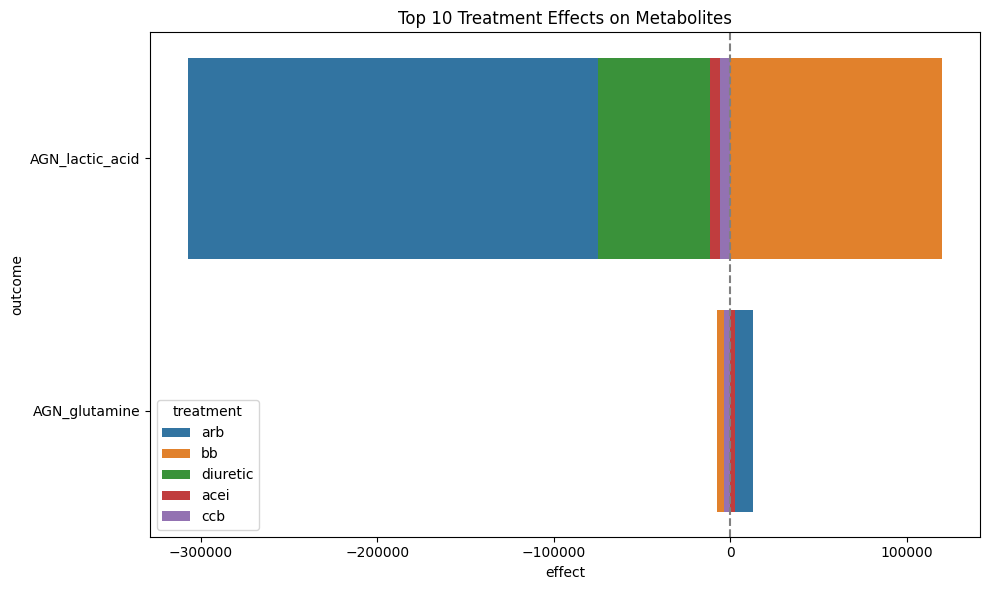

In [75]:
# Color-scale the effects — e.g., red for negative, blue for positive — no need for raw numbers.
# Simple bar plot for top effects
top_effects = df.sort_values("effect", key=abs, ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_effects, x="effect", y="outcome", hue="treatment", dodge=False)
plt.axvline(0, color='gray', linestyle='--')
plt.title("Top 10 Treatment Effects on Metabolites")
plt.tight_layout()
plt.show()



C:\Users\mondalsy\AppData\Local\Temp\ipykernel_22728\1824649715.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


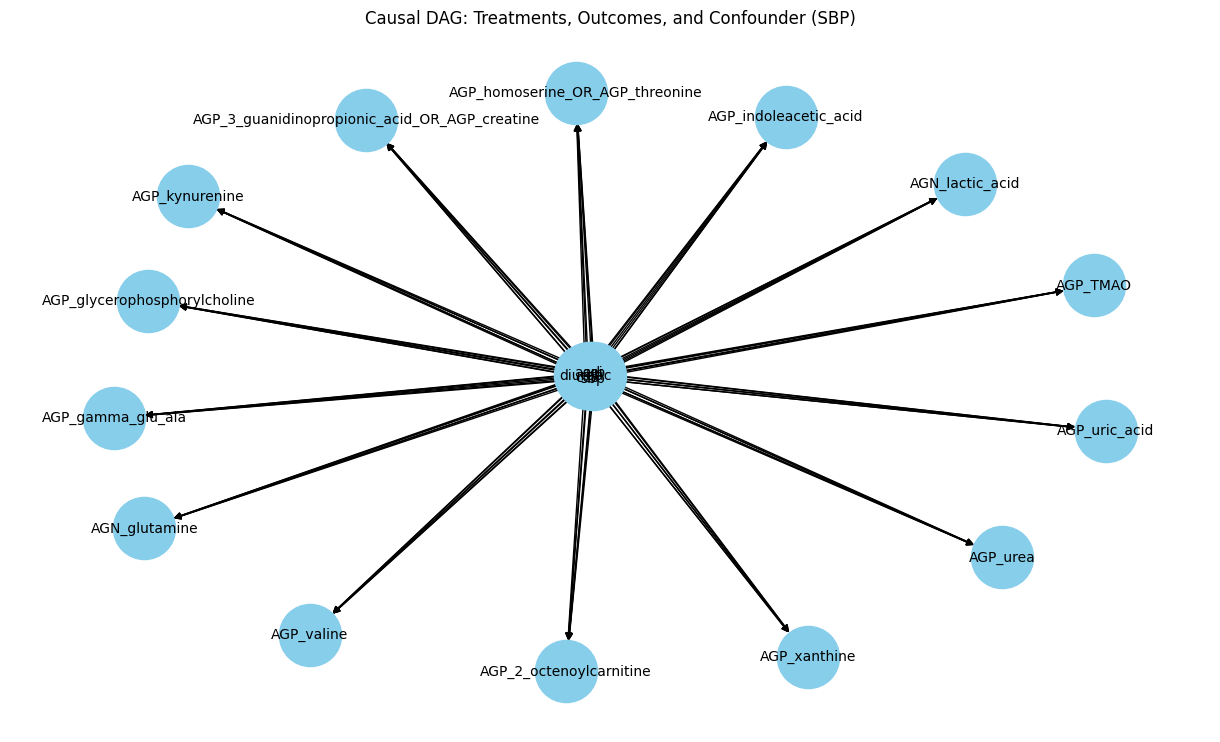

In [10]:
#  Build the DAG
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Load your data (optional here, but aligns with your workflow)
df = pd.read_csv("causal_effects_detailed3.csv")

# Get unique treatments and outcomes
treatments = df["treatment"].unique()
outcomes = df["outcome"].unique()
confounders = ["sbp"]

# Create directed graph
G = nx.DiGraph()

# Add edges: sbp → treatment, sbp → outcome, treatment → outcome
for t in treatments:
    G.add_edge("sbp", t)

for o in outcomes:
    G.add_edge("sbp", o)

for _, row in df.iterrows():
    G.add_edge(row["treatment"], row["outcome"])

# Draw graph
plt.figure(figsize=(12, 7))
pos = nx.spring_layout(G, k=0.5, iterations=100)
nx.draw(G, pos, with_labels=True, node_color="skyblue", node_size=2000, font_size=10, arrowsize=10)
plt.title("Causal DAG: Treatments, Outcomes, and Confounder (SBP)")
plt.tight_layout()
#plt.savefig("causal_dag.png", dpi=300)
plt.show()


C:\Users\mondalsy\AppData\Local\Temp\ipykernel_22728\1950093641.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


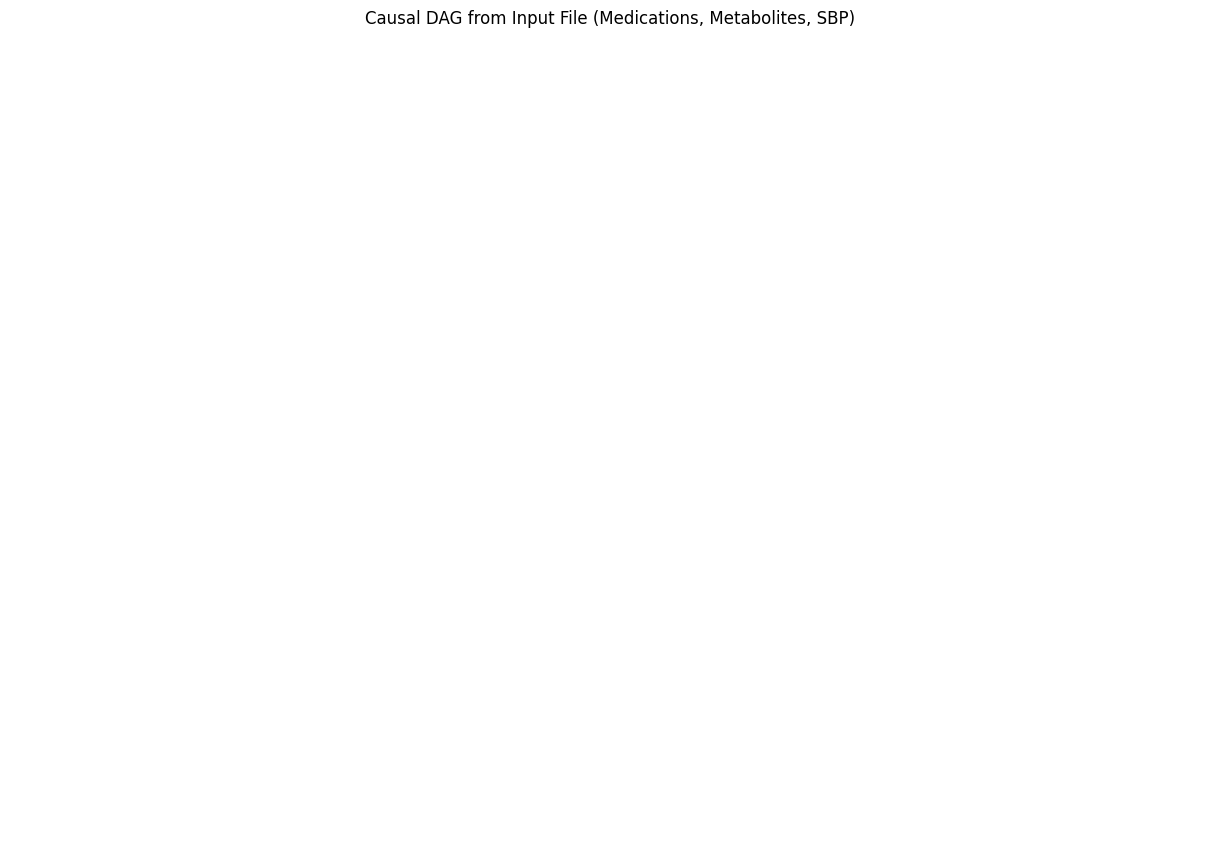

In [11]:

treatments = [col for col in df.columns if col in ["acei", "arb", "bb", "ccb", "diuretic"]]
#metabolites = [col for col in df.columns if col.startswith("AGN_")]
metabolites = [col for col in df.columns if col.startswith("AGN_") or col.startswith("AGP_")]
confounders = ["sbp"]

# Create a directed graph
G = nx.DiGraph()

# Add confounder → treatment edges
for t in treatments:
    G.add_edge("sbp", t)

# Add confounder → outcome edges
for m in metabolites:
    G.add_edge("sbp", m)

# Add treatment → outcome edges
for t in treatments:
    for m in metabolites:
        G.add_edge(t, m)

# Draw the DAG
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=0.6)
nx.draw(G, pos, with_labels=True, node_color="skyblue", node_size=1600, 
        edge_color="gray", font_size=12, font_weight="bold", arrowsize=11)
plt.title("Causal DAG from Input File (Medications, Metabolites, SBP)")
plt.tight_layout()
#plt.savefig("dag_from_input_file.png", dpi=300)
plt.show()


In [4]:
#Step 1: Estimation with Statistical Significance
#Replace your DoWhy loop with this version using statsmodels (for p-values & CIs):
    
import pandas as pd
import statsmodels.api as sm

file_path = "Extracted_LR_Selected_Features.xlsx"  # Replace with your actual file
df = pd.read_excel(file_path, sheet_name="AFHRI_AOC_Combined")  # Adjust sheet_name if required

treatments = [col for col in df.columns if col in ["acei", "arb", "bb", "ccb", "diuretic"]]
#metabolites = [col for col in df.columns if col.startswith("AGN_")]
metabolites = [col for col in df.columns if col.startswith("AGN_") or col.startswith("AGP_")]
confounders = ["sbp"]

results = []

for treatment in treatments:
    for outcome in metabolites:
        try:
            data = df[[treatment, outcome] + confounders].dropna()
            X = sm.add_constant(data[[treatment] + confounders])
            y = data[outcome]
            model = sm.OLS(y, X).fit()

            coef = model.params[treatment]
            pval = model.pvalues[treatment]
            ci_lower, ci_upper = model.conf_int().loc[treatment]

            results.append({
                "treatment": treatment,
                "outcome": outcome,
                "effect": coef,
                "p_value": pval,
                "ci_lower": ci_lower,
                "ci_upper": ci_upper
            })
        except Exception as e:
            print(f"Skipping {treatment} → {outcome}: {e}")

# Save results
results_df = pd.DataFrame(results)
results_df.to_csv("causal_effects_detailed3.csv", index=False)


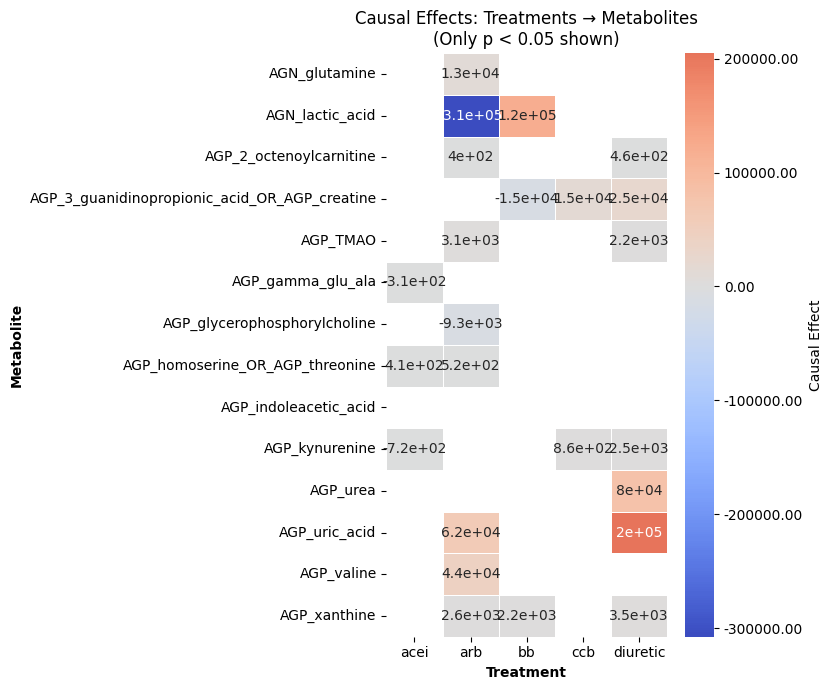

In [5]:
# Plot with Significance Masking
import seaborn as sns
import matplotlib.pyplot as plt

# Load results
df = pd.read_csv("causal_effects_detailed3.csv")

# Pivot effect and p-value
effects = df.pivot(index="outcome", columns="treatment", values="effect")
pvals = df.pivot(index="outcome", columns="treatment", values="p_value")

# Create significance mask (True = not significant)
mask = pvals > 0.05

plt.figure(figsize=(8, 0.5 * len(effects)))
sns.heatmap(
    effects,
    annot=True,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    mask=mask,  # Mask non-significant
    cbar_kws={"label": "Causal Effect", "format": "%.2f"}
)
plt.title("Causal Effects: Treatments → Metabolites\n(Only p < 0.05 shown)")
plt.xlabel("Treatment", fontweight="bold")
plt.ylabel("Metabolite", fontweight="bold")
plt.tight_layout()
#plt.savefig("causal_effects_significant_only.png", dpi=300)
plt.show()


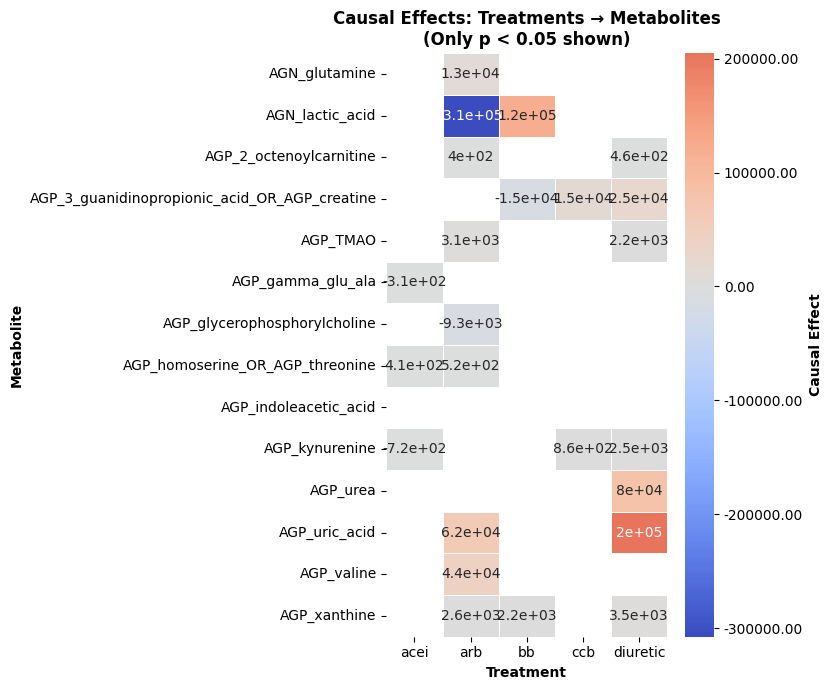

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Load results
df = pd.read_csv("causal_effects_detailed3.csv")

# Pivot effect and p-value
effects = df.pivot(index="outcome", columns="treatment", values="effect")
pvals = df.pivot(index="outcome", columns="treatment", values="p_value")

# Create significance mask (True = not significant)
mask = pvals > 0.05

plt.figure(figsize=(8, 0.5 * len(effects)))
ax = sns.heatmap(
    effects,
    annot=True,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    mask=mask,
    cbar_kws={"label": "Causal Effect", "format": "%.2f"}
)

# Bold axis titles
plt.title("Causal Effects: Treatments → Metabolites\n(Only p < 0.05 shown)", fontweight="bold")
plt.xlabel("Treatment", fontweight="bold")
plt.ylabel("Metabolite", fontweight="bold")

# Bold colorbar label
cbar = ax.collections[0].colorbar
cbar.ax.set_ylabel("Causal Effect", weight="bold")

plt.tight_layout()
plt.show()


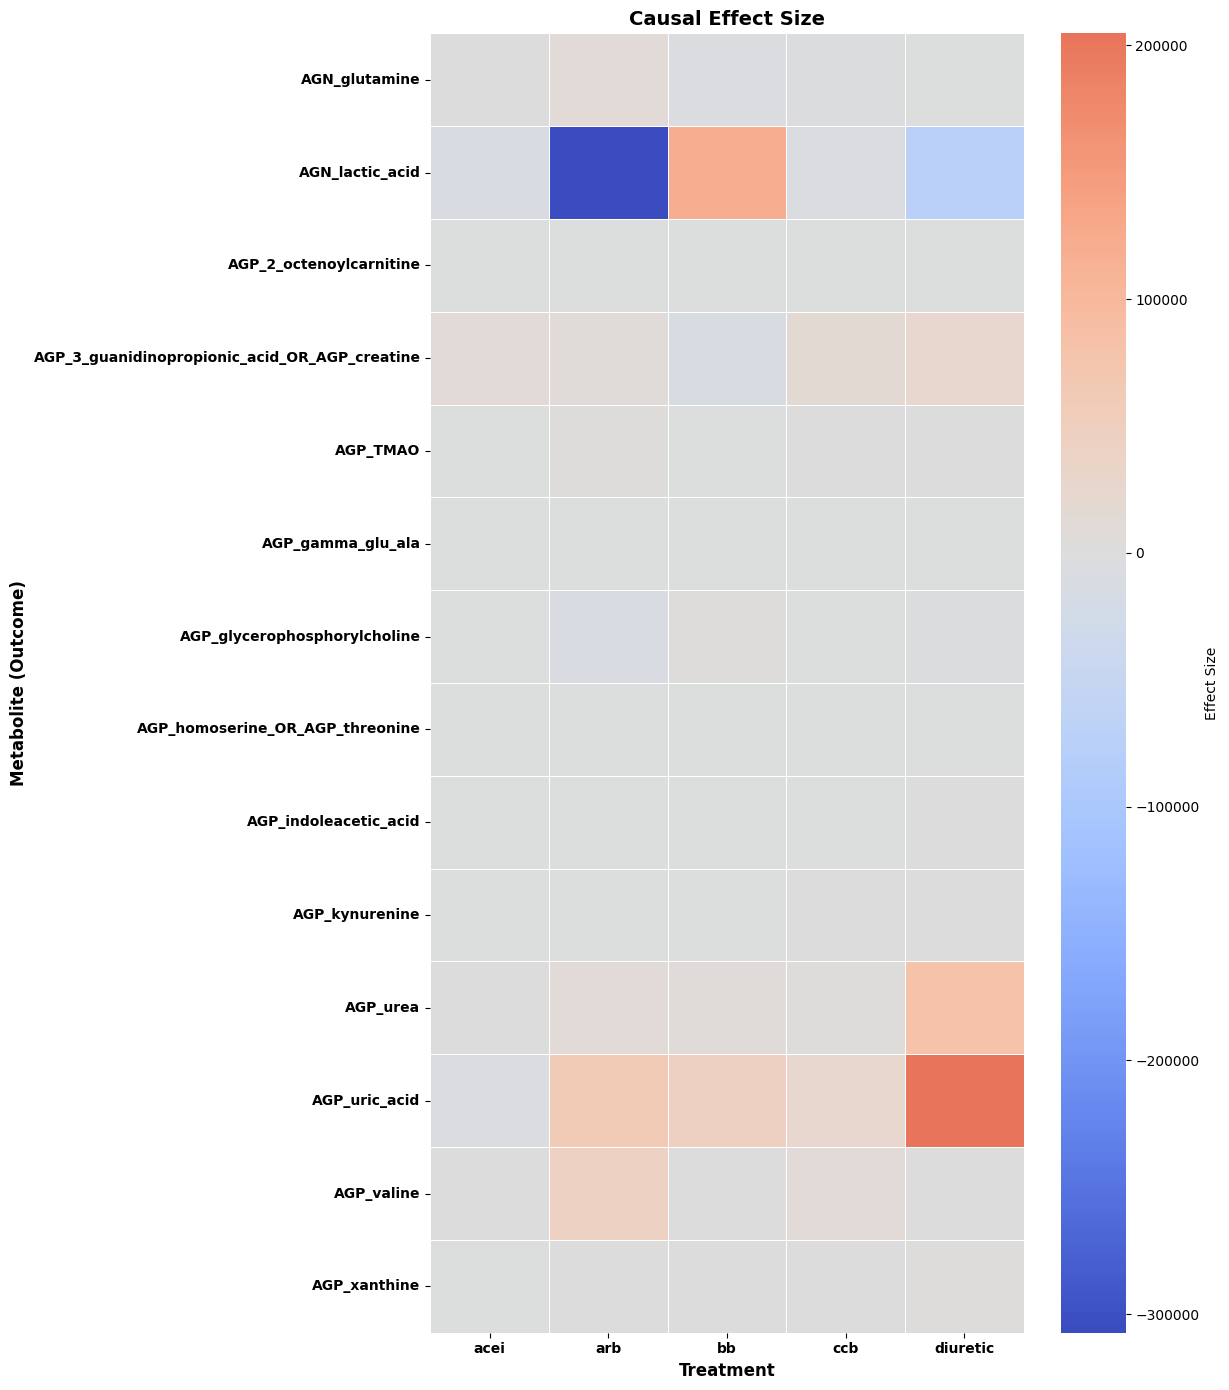

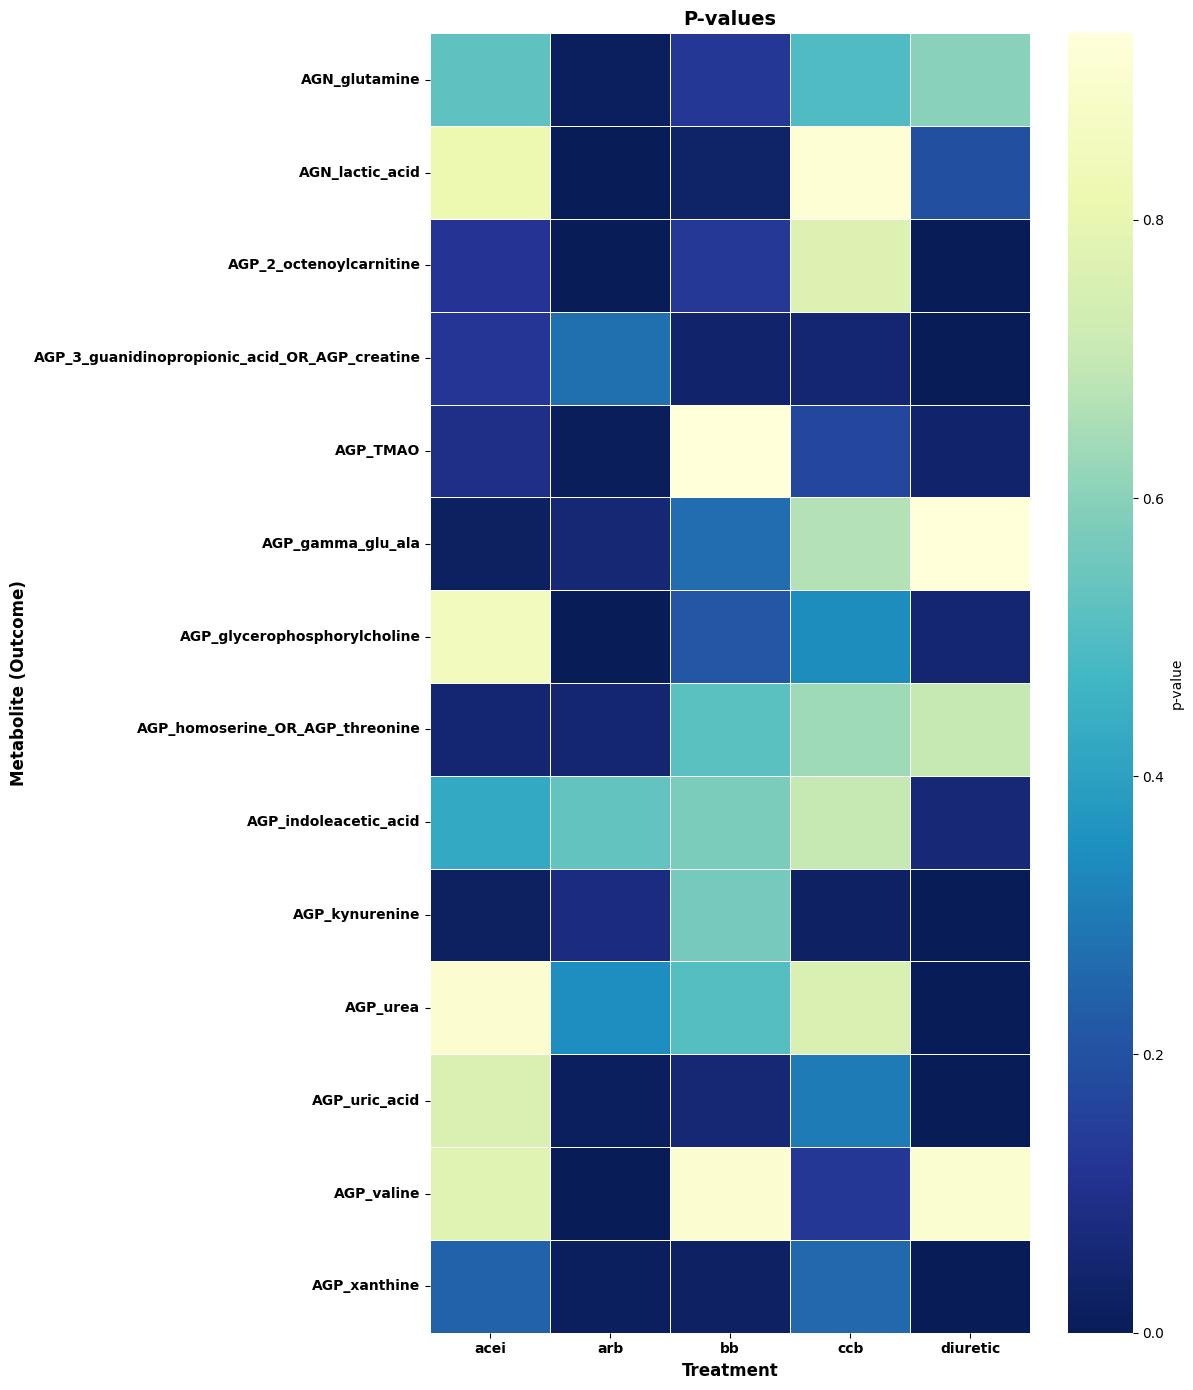

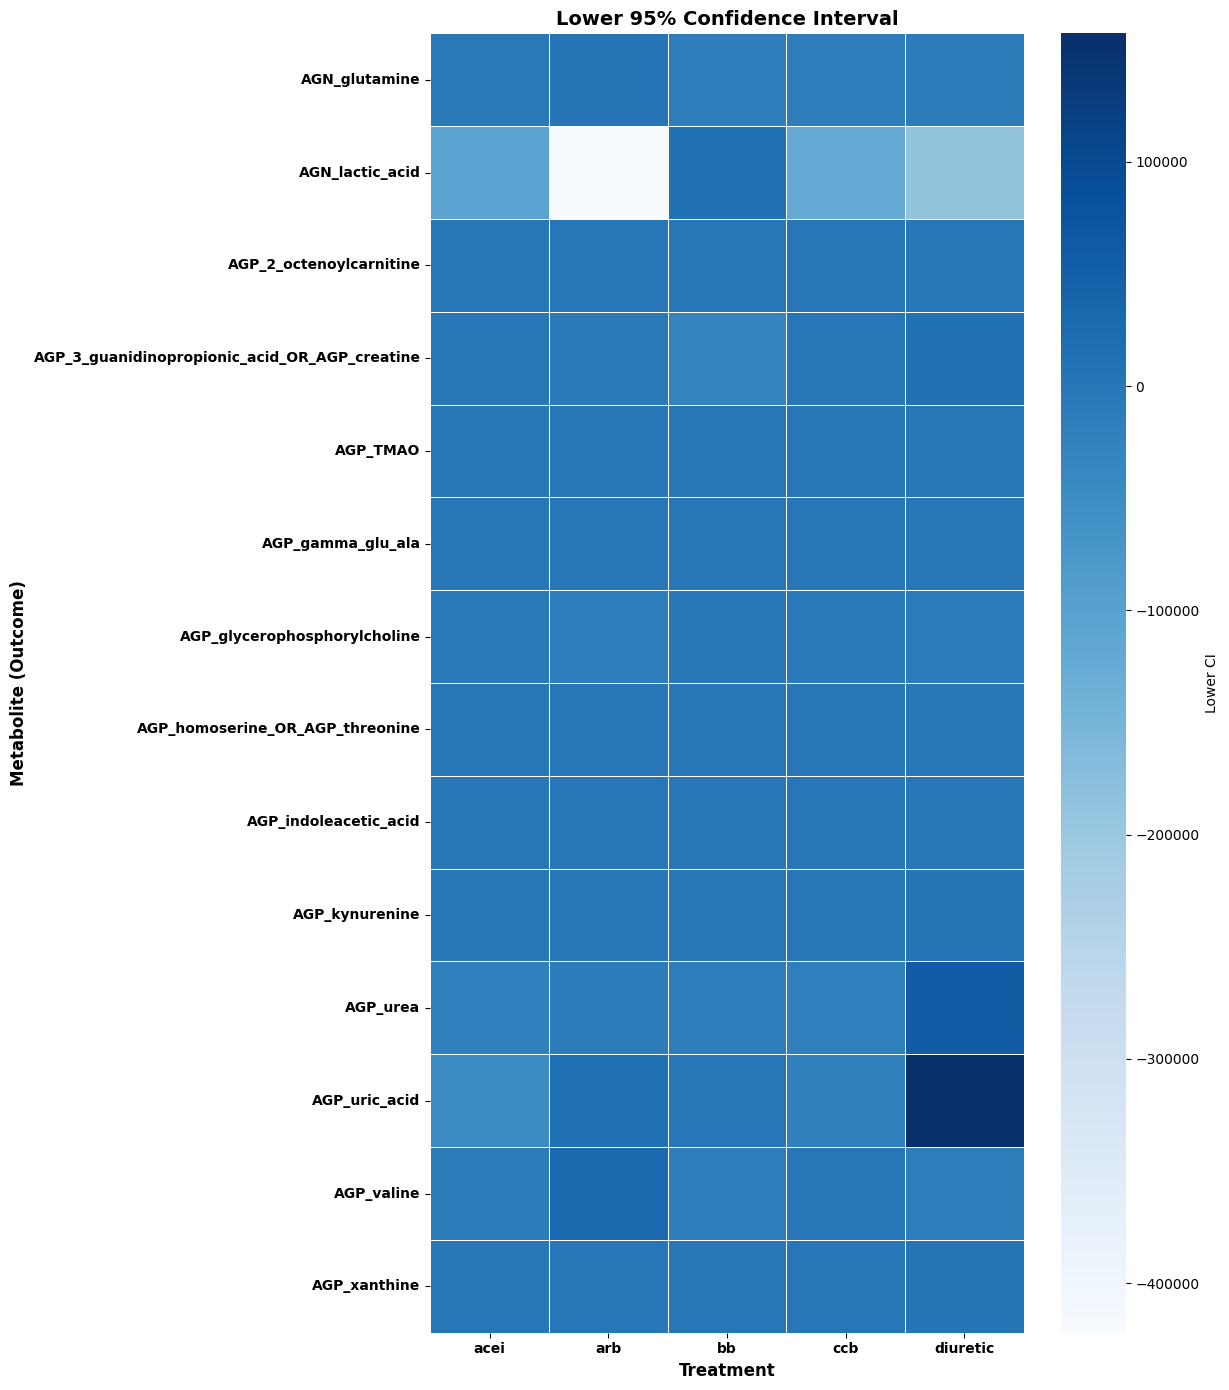

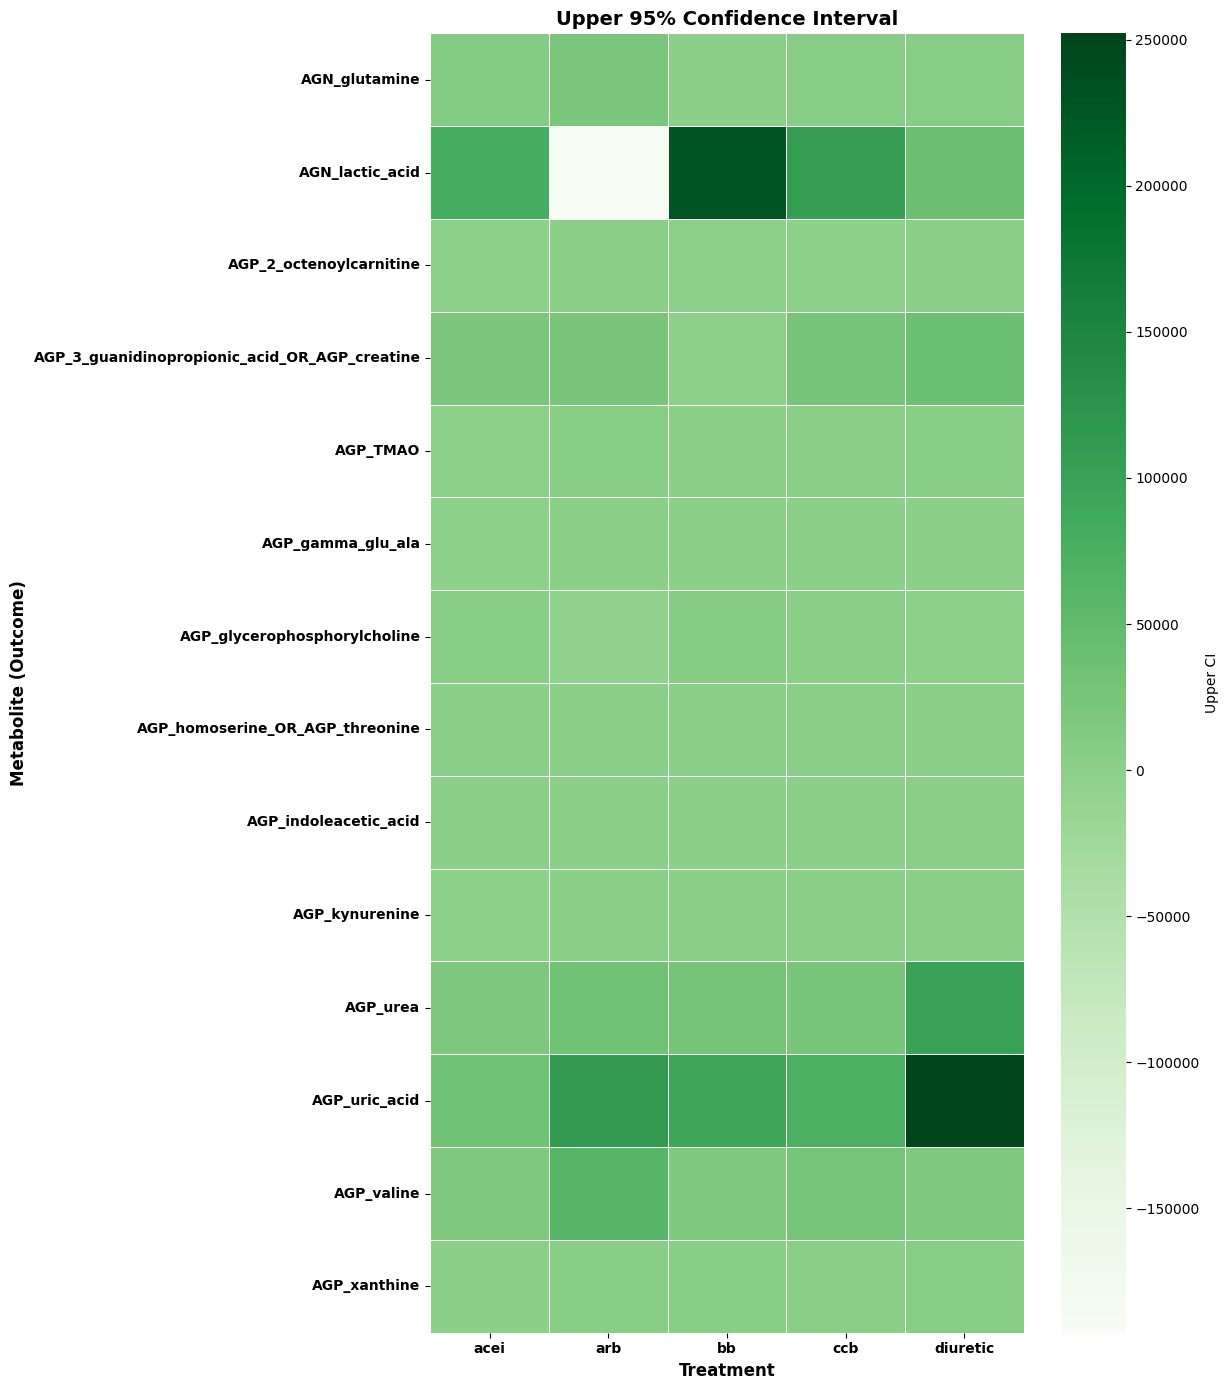

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("causal_effects_detailed3.csv")

# Pivot into matrices
effect_matrix = df.pivot(index="outcome", columns="treatment", values="effect")
pval_matrix = df.pivot(index="outcome", columns="treatment", values="p_value")
ci_lower_matrix = df.pivot(index="outcome", columns="treatment", values="ci_lower")
ci_upper_matrix = df.pivot(index="outcome", columns="treatment", values="ci_upper")

# Helper function to plot and save
def plot_heatmap(matrix, title, filename, cmap="coolwarm", center=None, fmt=".2f", cbar_label=""):
    plt.figure(figsize=(12, 1 * len(matrix)))
    sns.heatmap(matrix, annot=False, fmt=fmt, cmap=cmap, center=center,
                cbar_kws={"label": cbar_label}, linewidths=0.5)
    
    # Bold title and labels
    plt.title(title, fontweight='bold', fontsize=14)
    plt.xlabel("Treatment", fontweight='bold', fontsize=12)
    plt.ylabel("Metabolite (Outcome)", fontweight='bold', fontsize=12)

    # Bold tick labels
    ax = plt.gca()
    ax.set_xticklabels(ax.get_xticklabels(), fontweight='bold')
    ax.set_yticklabels(ax.get_yticklabels(), fontweight='bold')

    plt.tight_layout()
    # plt.savefig(filename, dpi=300)
    plt.show()
    #plt.savefig(filename, dpi=300)
    plt.show()

# Plot each matrix separately
plot_heatmap(effect_matrix, "Causal Effect Size", "effect_size_heatmap.png",
             cmap="coolwarm", center=0, cbar_label="Effect Size")

plot_heatmap(pval_matrix, "P-values", "p_value_heatmap.png",
             cmap="YlGnBu_r", fmt=".3f", cbar_label="p-value")

plot_heatmap(ci_lower_matrix, "Lower 95% Confidence Interval", "ci_lower_heatmap.png",
             cmap="Blues", fmt=".2f", cbar_label="Lower CI")

plot_heatmap(ci_upper_matrix, "Upper 95% Confidence Interval", "ci_upper_heatmap.png",
             cmap="Greens", fmt=".2f", cbar_label="Upper CI")


In [14]:
#  ighlight edges based on statistical strength (e.g. low p-values or large effect sizes) to enhance the causal DAG visualization.
# Focused DAG for Strong Effects


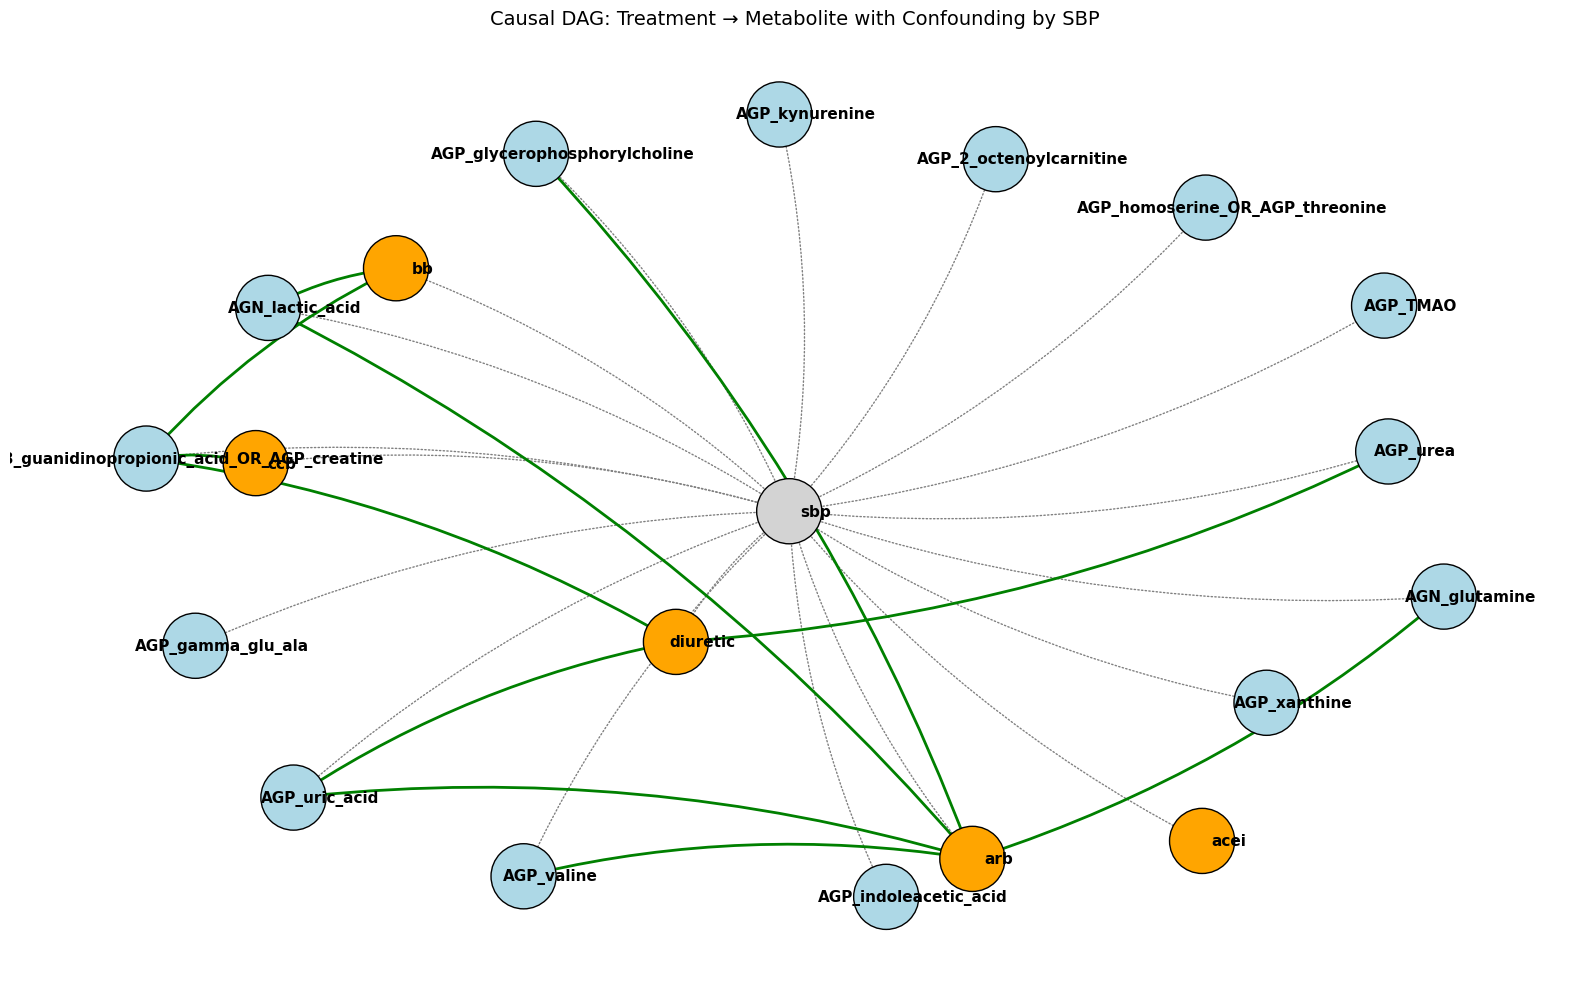

In [17]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("causal_effects_detailed3.csv")

# Define sets
treatments = df["treatment"].unique()
outcomes = df["outcome"].unique()
confounders = ["sbp"]

# Filter: significant and strong effects
threshold = 5000
filtered_df = df[(df["p_value"] < 0.05) & (df["effect"].abs() > threshold)]

# Create graph
G = nx.DiGraph()

# Add nodes with attributes
for t in treatments:
    G.add_node(t, type="treatment")
for o in outcomes:
    G.add_node(o, type="outcome")
for c in confounders:
    G.add_node(c, type="confounder")

# Add edges
for c in confounders:
    for t in treatments:
        G.add_edge(c, t, type="confounding")
    for o in outcomes:
        G.add_edge(c, o, type="confounding")

for _, row in filtered_df.iterrows():
    G.add_edge(row["treatment"], row["outcome"], type="treatment_effect", weight=row["effect"])

# Set positions
pos = nx.spring_layout(G, k=0.6, iterations=100)

# Define node colors
node_colors = []
for node in G.nodes():
    ntype = G.nodes[node]["type"]
    if ntype == "treatment":
        node_colors.append("orange")
    elif ntype == "outcome":
        node_colors.append("lightblue")
    else:
        node_colors.append("lightgray")

# Draw nodes
plt.figure(figsize=(16, 10))
nx.draw_networkx_nodes(G, pos, node_color=node_colors, edgecolors="black", node_size=2200)

# Draw edges with different styles
treat_edges = [(u, v) for u, v, d in G.edges(data=True) if d["type"] == "treatment_effect"]
confound_edges = [(u, v) for u, v, d in G.edges(data=True) if d["type"] == "confounding"]

nx.draw_networkx_edges(
    G, pos,
    edgelist=confound_edges,
    edge_color="gray",
    style="dotted",
    arrows=True,
    arrowsize=15,
    connectionstyle="arc3,rad=0.1"
)

nx.draw_networkx_edges(
    G, pos,
    edgelist=treat_edges,
    edge_color="green",
    width=2,
    arrows=True,
    arrowsize=20,
    connectionstyle="arc3,rad=0.1"
)

# Draw labels beside nodes
label_pos = {k: (v[0] + 0.04, v[1]) for k, v in pos.items()}
nx.draw_networkx_labels(G, label_pos, font_size=11, font_weight="bold")

# Final adjustments
plt.title("Causal DAG: Treatment → Metabolite with Confounding by SBP", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()


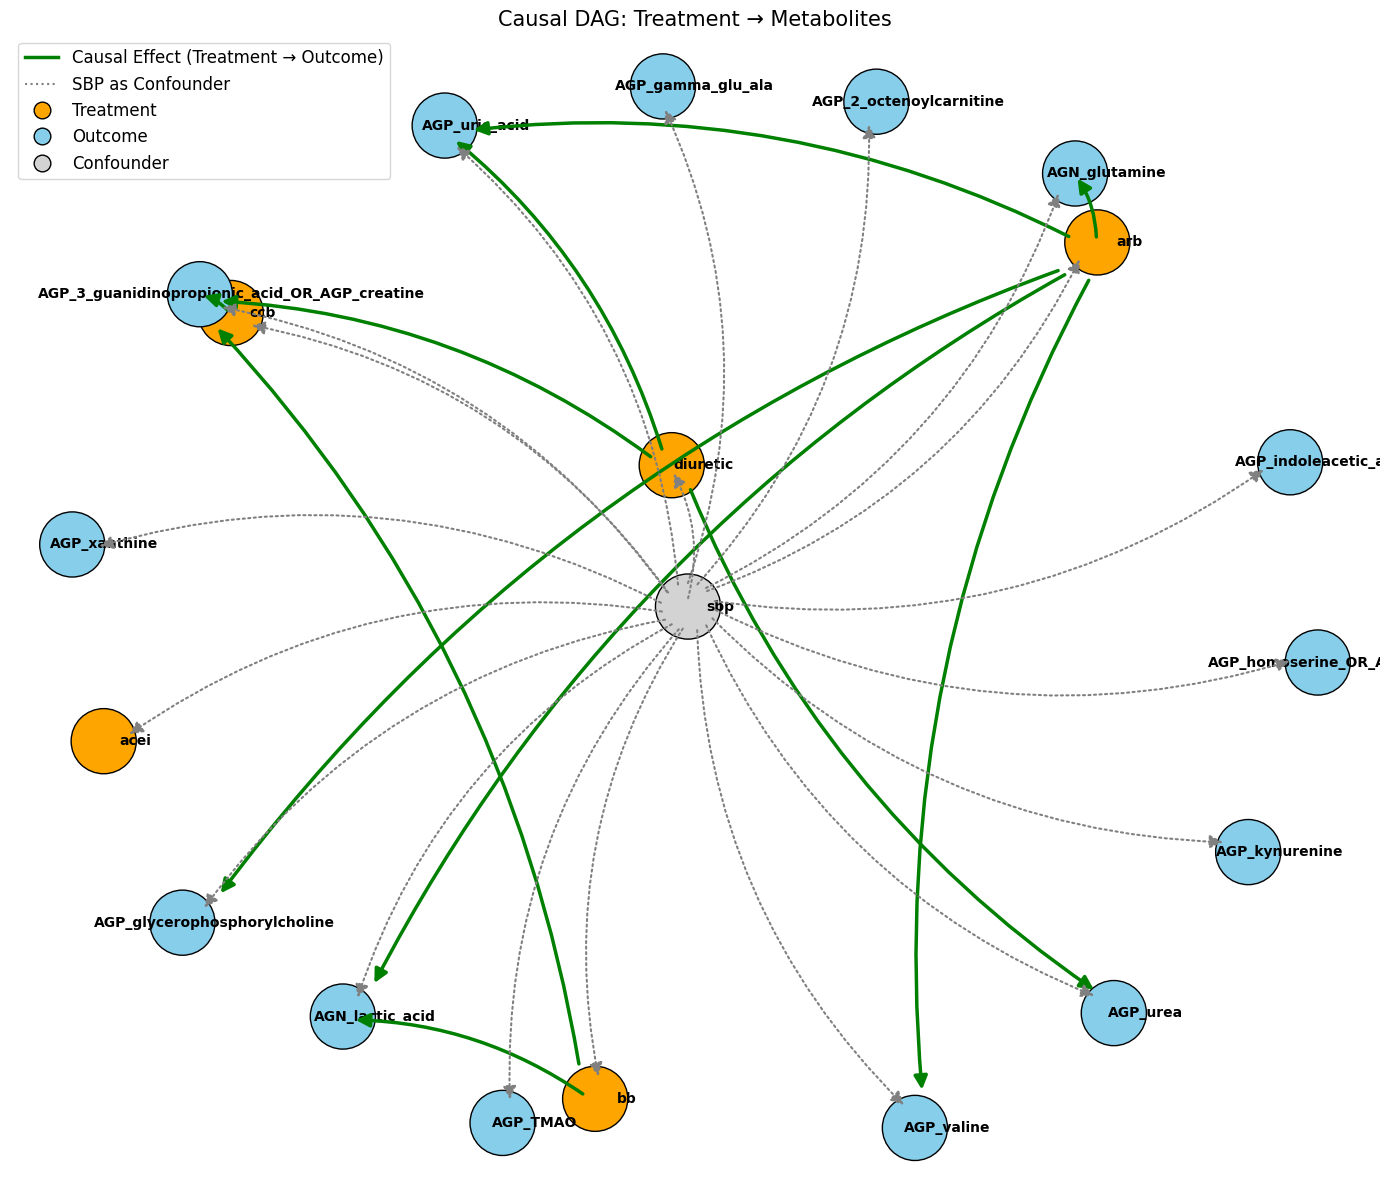

In [37]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
import numpy as np

# Load data
df = pd.read_csv("causal_effects_detailed3.csv")

# Define groups
treatments = df["treatment"].unique()
outcomes = df["outcome"].unique()
confounders = ["sbp"]

# Filter significant, strong effects
threshold = 5000
filtered_df = df[(df["p_value"] < 0.05) & (df["effect"].abs() > threshold)]

# Create directed graph
G = nx.DiGraph()

# Add nodes with categories
for t in treatments:
    G.add_node(t, group="treatment")
for o in outcomes:
    G.add_node(o, group="outcome")
for c in confounders:
    G.add_node(c, group="confounder")

# Add edges
for c in confounders:
    for t in treatments:
        G.add_edge(c, t, relation="confounding")
    for o in outcomes:
        G.add_edge(c, o, relation="confounding")

for _, row in filtered_df.iterrows():
    G.add_edge(row["treatment"], row["outcome"], relation="causal", weight=row["effect"])

# Positioning
pos = nx.spring_layout(G, k=1.2, iterations=200)

# Node colors
node_colors = []
for node in G.nodes():
    group = G.nodes[node]["group"]
    if group == "treatment":
        node_colors.append("orange")
    elif group == "outcome":
        node_colors.append("skyblue")
    else:
        node_colors.append("lightgray")

# Plot setup
fig, ax = plt.subplots(figsize=(14, 12))
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2200, edgecolors="black", ax=ax)

# Draw node labels beside nodes
label_pos = {k: (v[0] + 0.05, v[1]) for k, v in pos.items()}
nx.draw_networkx_labels(G, label_pos, font_size=10, font_weight="bold", ax=ax)

# Custom arrow drawing function
def offset_pos(posA, posB, fraction=0.12):
    vec = np.array(posB) - np.array(posA)
    return tuple(np.array(posA) + fraction * vec)

for u, v, data in G.edges(data=True):
    if data["relation"] == "confounding":
        color = "gray"
        style = "dotted"
        width = 1.5
        rad = 0.2
    else:
        color = "green"
        style = "solid"
        width = 2.5
        rad = 0.15

    posA = offset_pos(pos[u], pos[v], 0.04)
    posB = offset_pos(pos[v], pos[u], 0.04)

    arrow = FancyArrowPatch(
        posA=posA, posB=posB,
        connectionstyle=f"arc3,rad={rad}",
        arrowstyle="-|>",
        color=color,
        linewidth=width,
        linestyle=style,
        mutation_scale=20,
        zorder=10
    )
    ax.add_patch(arrow)

# Add legend manually
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color="green", lw=2.5, label="Causal Effect (Treatment → Outcome)"),
    Line2D([0], [0], color="gray", lw=1.5, linestyle="dotted", label="SBP as Confounder"),
    Line2D([0], [0], marker='o', color='w', label='Treatment', markerfacecolor='orange', markersize=12, markeredgecolor='black'),
    Line2D([0], [0], marker='o', color='w', label='Outcome', markerfacecolor='skyblue', markersize=12, markeredgecolor='black'),
    Line2D([0], [0], marker='o', color='w', label='Confounder', markerfacecolor='lightgray', markersize=12, markeredgecolor='black')
]
ax.legend(handles=legend_elements, loc="upper left", fontsize=12, frameon=True)

plt.title("Causal DAG: Treatment → Metabolites", fontsize=15)
plt.axis("off")
plt.tight_layout()
plt.show()


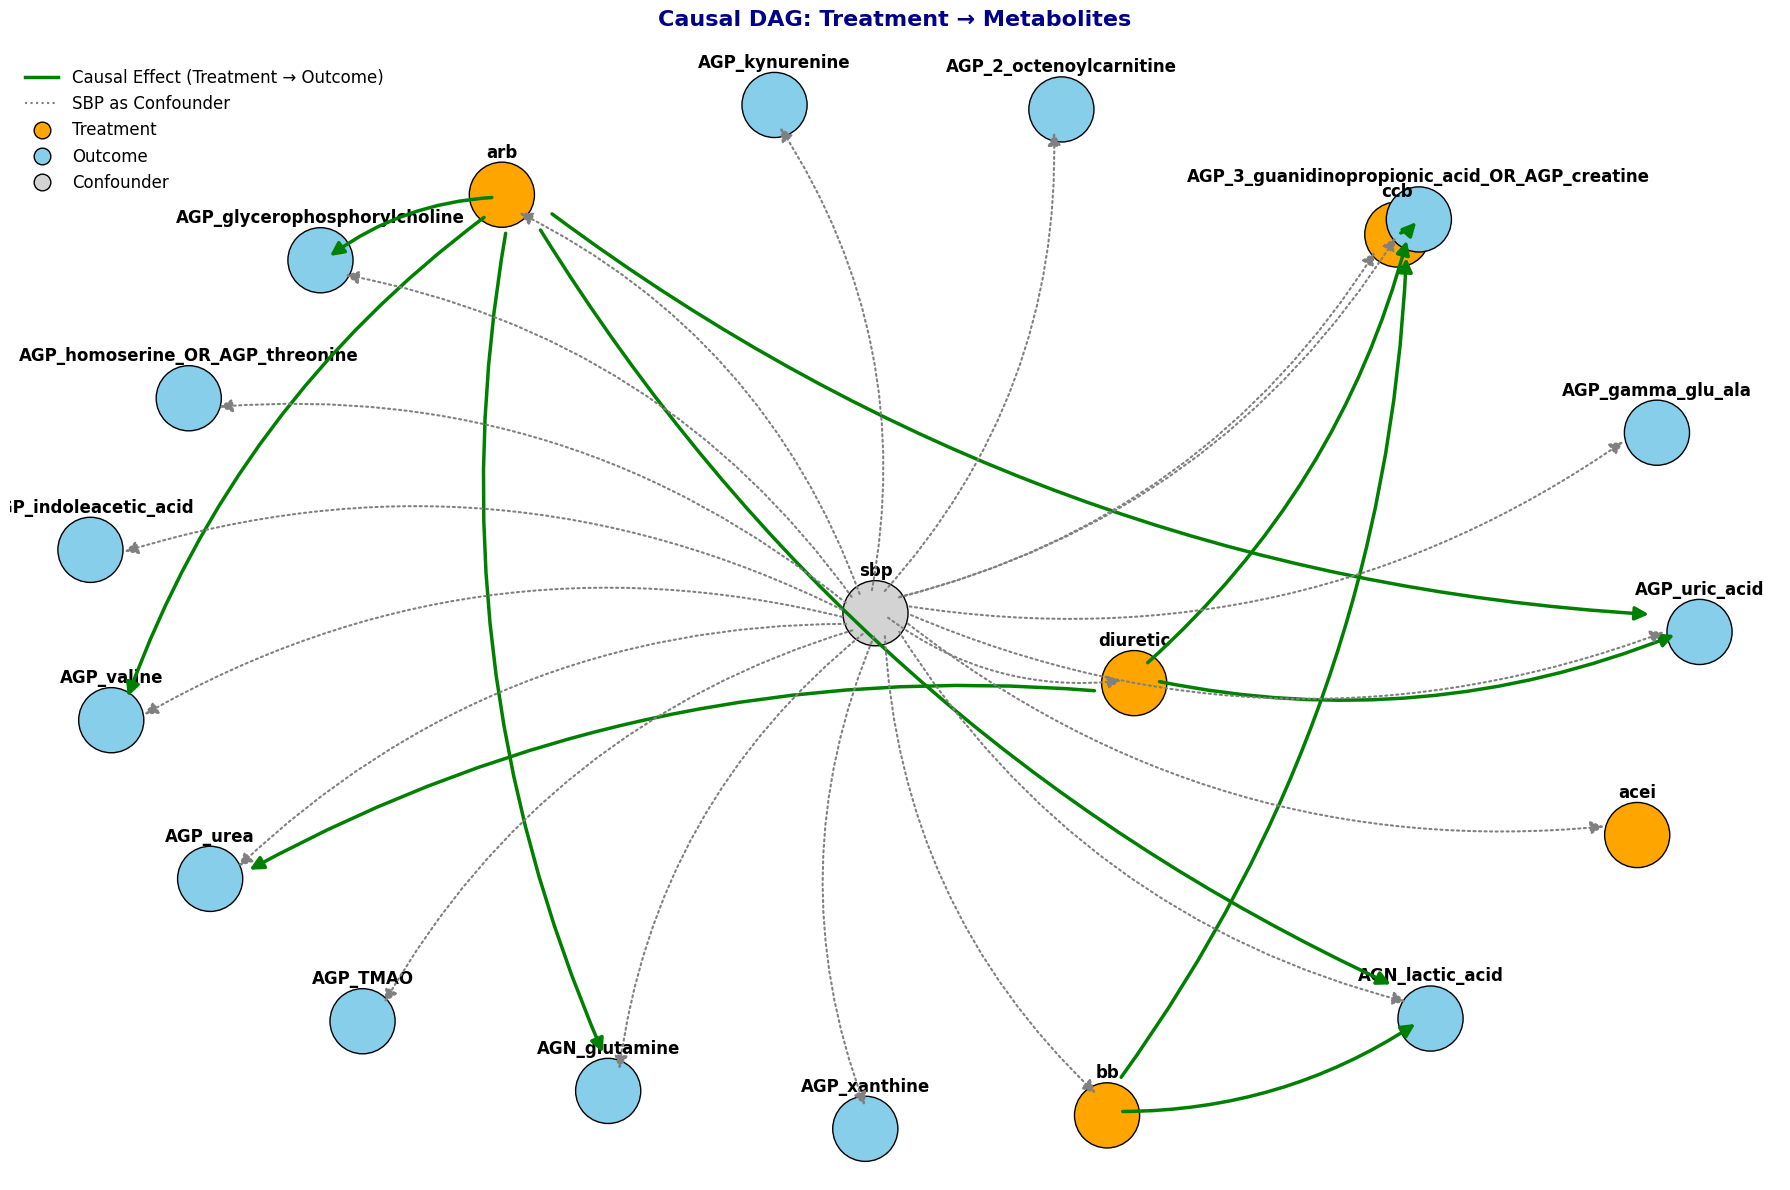

In [60]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
import numpy as np

# Load data
df = pd.read_csv("causal_effects_detailed3.csv")

# Define groups
treatments = df["treatment"].unique()
outcomes = df["outcome"].unique()
confounders = ["sbp"]

# Filter significant, strong effects
threshold = 5000
filtered_df = df[(df["p_value"] < 0.05) & (df["effect"].abs() > threshold)]

# Create directed graph
G = nx.DiGraph()

# Add nodes with categories
for t in treatments:
    G.add_node(t, group="treatment")
for o in outcomes:
    G.add_node(o, group="outcome")
for c in confounders:
    G.add_node(c, group="confounder")

# Add edges
for c in confounders:
    for t in treatments:
        G.add_edge(c, t, relation="confounding")
    for o in outcomes:
        G.add_edge(c, o, relation="confounding")

for _, row in filtered_df.iterrows():
    G.add_edge(row["treatment"], row["outcome"], relation="causal", weight=row["effect"])

# Positioning
pos = nx.spring_layout(G, k=1.2, iterations=200)

# Node colors
node_colors = []
for node in G.nodes():
    group = G.nodes[node]["group"]
    if group == "treatment":
        node_colors.append("orange")
    elif group == "outcome":
        node_colors.append("skyblue")
    else:
        node_colors.append("lightgray")

# Plot setup
fig, ax = plt.subplots(figsize=(18, 12))
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2200, edgecolors="black", ax=ax)

# Custom arrow drawing function
def offset_pos(posA, posB, fraction=0.12):
    vec = np.array(posB) - np.array(posA)
    return tuple(np.array(posA) + fraction * vec)

for u, v, data in G.edges(data=True):
    if data["relation"] == "confounding":
        color = "gray"
        style = "dotted"
        width = 1.5
        rad = 0.2
    else:
        color = "green"
        style = "solid"
        width = 2.5
        rad = 0.15

    posA = offset_pos(pos[u], pos[v], 0.04)
    posB = offset_pos(pos[v], pos[u], 0.04)

    arrow = FancyArrowPatch(
        posA=posA, posB=posB,
        connectionstyle=f"arc3,rad={rad}",
        arrowstyle="-|>",
        color=color,
        linewidth=width,
        linestyle=style,
        mutation_scale=20,
        zorder=10
    )
    ax.add_patch(arrow)

# Adjust label positions to be outside the nodes
label_pos = {}
for k, v in pos.items():
    label_pos[k] = (v[0], v[1] + 0.08)  # Adjust the y-position to move labels above nodes

nx.draw_networkx_labels(G, label_pos, font_size=12, font_weight="bold", ax=ax)

# Add legend manually
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color="green", lw=2.5, label="Causal Effect (Treatment → Outcome)"),
    Line2D([0], [0], color="gray", lw=1.5, linestyle="dotted", label="SBP as Confounder"),
    Line2D([0], [0], marker='o', color='w', label='Treatment', markerfacecolor='orange', markersize=12, markeredgecolor='black'),
    Line2D([0], [0], marker='o', color='w', label='Outcome', markerfacecolor='skyblue', markersize=12, markeredgecolor='black'),
    Line2D([0], [0], marker='o', color='w', label='Confounder', markerfacecolor='lightgray', markersize=12, markeredgecolor='black')
]
ax.legend(handles=legend_elements, loc="upper left", fontsize=12, frameon=False)

#plt.title("Causal DAG: Treatment → Metabolites", fontsize=16)
plt.title("Causal DAG: Treatment → Metabolites", fontsize=16, fontweight="bold", color="darkblue", pad=20)

plt.axis("off")
plt.tight_layout()
# plt.savefig("causal_dag_plot.png", dpi=300, bbox_inches="tight", transparent=False)
plt.show()


In [21]:
# a) Does SBP influence ARB usage (binary)?
import statsmodels.api as sm

model = sm.Logit(df['arb'], sm.add_constant(df[['sbp']])).fit()
print(model.summary())


Optimization terminated successfully.
         Current function value: 0.504018
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                    arb   No. Observations:                 1669
Model:                          Logit   Df Residuals:                     1667
Method:                           MLE   Df Model:                            1
Date:                Sun, 04 May 2025   Pseudo R-squ.:                0.001334
Time:                        23:38:23   Log-Likelihood:                -841.21
converged:                       True   LL-Null:                       -842.33
Covariance Type:            nonrobust   LLR p-value:                    0.1338
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.9784      0.413     -4.791      0.000      -2.788      -1.169
sbp            0.0043      0.

In [25]:
# b) Does SBP influence metabolite X (continuous)?
import pandas as pd
import statsmodels.api as sm



# Variables
treatments = ["acei", "arb", "bb", "ccb", "diuretic"]
metabolites = [col for col in df.columns if col.startswith("AGN_") or col.startswith("AGP_")]
confounder = "sbp"

# 1. Check SBP → Treatment (logistic regression)
print("### SBP → Treatment ###")
for t in treatments:
    try:
        data = df[[t, confounder]].dropna()
        model = sm.Logit(data[t], sm.add_constant(data[[confounder]])).fit(disp=False)
        pval = model.pvalues[confounder]
        print(f"SBP → {t}: p-value = {pval:.4f}")
    except Exception as e:
        print(f"Skipping {t}: {e}")

# 2. Check SBP → Each Metabolite (linear regression)
print("\n### SBP → Metabolite ###")
for m in metabolites:
    try:
        data = df[[m, confounder]].dropna()
        model = sm.OLS(data[m], sm.add_constant(data[[confounder]])).fit()
        pval = model.pvalues[confounder]
        print(f"SBP → {m}: p-value = {pval:.4f}")
    except Exception as e:
        print(f"Skipping {m}: {e}")



### SBP → Treatment ###
SBP → acei: p-value = 0.1152
SBP → arb: p-value = 0.1328
SBP → bb: p-value = 0.9363
SBP → ccb: p-value = 0.0403
SBP → diuretic: p-value = 0.0270

### SBP → Metabolite ###
SBP → AGN_lactic_acid: p-value = 0.0000
SBP → AGP_2_octenoylcarnitine: p-value = 0.0115
SBP → AGP_urea: p-value = 0.0002
SBP → AGP_valine: p-value = 0.0000
SBP → AGP_indoleacetic_acid: p-value = 0.1563
SBP → AGP_gamma_glu_ala: p-value = 0.0124
SBP → AGP_kynurenine: p-value = 0.0200
SBP → AGN_glutamine: p-value = 0.0056
SBP → AGP_3_guanidinopropionic_acid_OR_AGP_creatine: p-value = 0.0102
SBP → AGP_xanthine: p-value = 0.1268
SBP → AGP_TMAO: p-value = 0.8260
SBP → AGP_glycerophosphorylcholine: p-value = 0.0096
SBP → AGP_homoserine_OR_AGP_threonine: p-value = 0.0137
SBP → AGP_uric_acid: p-value = 0.0030


In [2]:

# Identify variables
treatments = [col for col in df.columns if col in ["acei", "arb", "bb", "ccb", "diuretic"]]
metabolites = [col for col in df.columns if col.startswith("AGN_")]
confounders = ["sbp"]

# Loop through each treatment-metabolite pair
results = []

for treatment in treatments:
    for outcome in metabolites:
        print(f"\n--- Causal Effect: {treatment} → {outcome} ---")
        
        # Build model
        model = CausalModel(
            data=df,
            treatment=treatment,
            outcome=outcome,
            common_causes=confounders
        )
        
        # Identify and estimate effect
        identified_estimand = model.identify_effect()
        estimate = model.estimate_effect(
            identified_estimand,
            method_name="backdoor.linear_regression"
        )
        
        print(f"Estimated Effect of {treatment} on {outcome}: {estimate.value}")
        results.append({
            "treatment": treatment,
            "outcome": outcome,
            "effect": estimate.value
        })

        # Optional: Refutation (e.g., placebo test)
        refutation = model.refute_estimate(
            identified_estimand, estimate, method_name="placebo_treatment_refuter"
        )
        print("Refutation result:", refutation)



--- Causal Effect: acei → AGN_lactic_acid ---
Estimated Effect of acei on AGN_lactic_acid: -11183.193635433447
Refutation result: Refute: Use a Placebo Treatment
Estimated effect:-11183.193635433447
New effect:-9591.611231973833
p value:0.86


--- Causal Effect: acei → AGN_glutamine ---
Estimated Effect of acei on AGN_glutamine: 2580.341550596175
Refutation result: Refute: Use a Placebo Treatment
Estimated effect:2580.341550596175
New effect:127.71889001168368
p value:0.88


--- Causal Effect: arb → AGN_lactic_acid ---
Estimated Effect of arb on AGN_lactic_acid: -307369.5047914167
Refutation result: Refute: Use a Placebo Treatment
Estimated effect:-307369.5047914167
New effect:-9482.792695909891
p value:0.88


--- Causal Effect: arb → AGN_glutamine ---
Estimated Effect of arb on AGN_glutamine: 12620.821811354312
Refutation result: Refute: Use a Placebo Treatment
Estimated effect:12620.821811354312
New effect:328.2084886426543
p value:0.94


--- Causal Effect: bb → AGN_lactic_acid ---


In [3]:
pd.DataFrame(results).to_csv("causal_effects.csv", index=False)


In [10]:
import statsmodels.api as sm

# Example: ACEI → AGN_lactic_acid adjusted for sbp
X = df[["acei", "sbp"]]
X = sm.add_constant(X)
y = df["AGN_lactic_acid"]

model = sm.OLS(y, X).fit()
print(model.summary())  # Contains coefficients, p-values, R-squared


                            OLS Regression Results                            
Dep. Variable:        AGN_lactic_acid   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     9.829
Date:                Thu, 01 May 2025   Prob (F-statistic):           5.71e-05
Time:                        13:17:12   Log-Likelihood:                -25372.
No. Observations:                1669   AIC:                         5.075e+04
Df Residuals:                    1666   BIC:                         5.077e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.708e+06   1.64e+05     10.428      0.0

In [ ]:
# (SBP may biologically affect some metabolite levels — e.g., via perfusion or 
# systemic physiological effects) is a valid causal link and should absolutely be included in your DAG.